# 📊 ChampIntel — Exploratory Data Analysis (EDA)

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
RAW_DATA_PATH = os.path.join("..", "datasets", "raw", "matches.csv")
print("✅ Library EDA siap!")

✅ Library EDA siap!


Sel 2 (Code) — Import Library

In [3]:
df = pd.read_csv(RAW_DATA_PATH)
df.columns = df.columns.str.strip()

print(f"📊 Total Pertandingan: {df.shape[0]:,} laga")
print(f"📋 Total Kolom: {df.shape[1]}")
df.head(5)

📊 Total Pertandingan: 25,979 laga
📋 Total Kolom: 9


,date,season,stage,home_team,away_team,score,home_goals,away_goals,result
0,2008-08-17 00:00:00,2008/2009,1,KRC Genk,Beerschot AC,1–1,1,1,Draw
1,2008-08-16 00:00:00,2008/2009,1,SV Zulte-Waregem,Sporting Lokeren,0–0,0,0,Draw
2,2008-08-16 00:00:00,2008/2009,1,KSV Cercle Brugge,RSC Anderlecht,0–3,0,3,Away Win
3,2008-08-17 00:00:00,2008/2009,1,KAA Gent,RAEC Mons,5–0,5,0,Home Win
4,2008-08-16 00:00:00,2008/2009,1,FCV Dender EH,Standard de Liège,1–3,1,3,Away Win


Memuat Data & Ringkasan Struktur

In [4]:
df = pd.read_csv(RAW_DATA_PATH)
df.columns = df.columns.str.strip()

print(f"📊 Total Pertandingan: {df.shape[0]:,} laga")
print(f"📋 Total Kolom: {df.shape[1]}")
df.head(5)

📊 Total Pertandingan: 25,979 laga
📋 Total Kolom: 9


,date,season,stage,home_team,away_team,score,home_goals,away_goals,result
0,2008-08-17 00:00:00,2008/2009,1,KRC Genk,Beerschot AC,1–1,1,1,Draw
1,2008-08-16 00:00:00,2008/2009,1,SV Zulte-Waregem,Sporting Lokeren,0–0,0,0,Draw
2,2008-08-16 00:00:00,2008/2009,1,KSV Cercle Brugge,RSC Anderlecht,0–3,0,3,Away Win
3,2008-08-17 00:00:00,2008/2009,1,KAA Gent,RAEC Mons,5–0,5,0,Home Win
4,2008-08-16 00:00:00,2008/2009,1,FCV Dender EH,Standard de Liège,1–3,1,3,Away Win


Visualisasi Distribusi Kemenangan (Home vs Draw vs Away)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13204\152428768.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='result', order=['Home Win', 'Draw', 'Away Win'], palette=['#3b82f6', '#f59e0b', '#6366f1'])


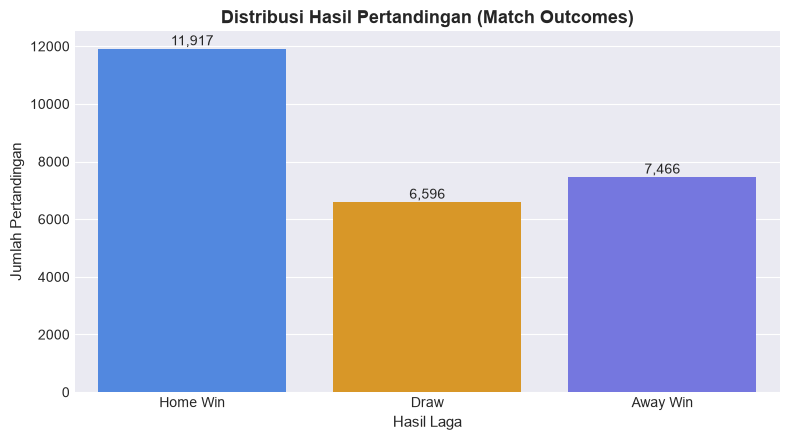

In [5]:
plt.figure(figsize=(8, 4.5))
ax = sns.countplot(data=df, x='result', order=['Home Win', 'Draw', 'Away Win'], palette=['#3b82f6', '#f59e0b', '#6366f1'])
plt.title('Distribusi Hasil Pertandingan (Match Outcomes)', fontsize=13, fontweight='bold')
plt.xlabel('Hasil Laga', fontsize=11)
plt.ylabel('Jumlah Pertandingan', fontsize=11)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

Visualisasi Perbandingan Gol Kandang vs Tandang

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13204\178617786.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=goals_df, x='Kategori', y='Total Gol', palette=['#3b82f6', '#818cf8'])


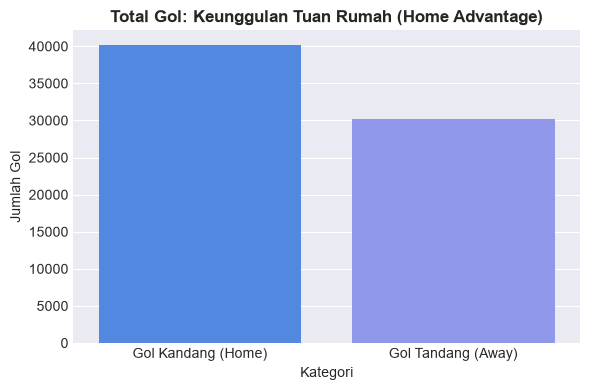

In [6]:
df['home_goals'] = pd.to_numeric(df['home_goals'], errors='coerce')
df['away_goals'] = pd.to_numeric(df['away_goals'], errors='coerce')

goals_df = pd.DataFrame({
    'Kategori': ['Gol Kandang (Home)', 'Gol Tandang (Away)'],
    'Total Gol': [df['home_goals'].sum(), df['away_goals'].sum()]
})

plt.figure(figsize=(6, 4))
sns.barplot(data=goals_df, x='Kategori', y='Total Gol', palette=['#3b82f6', '#818cf8'])
plt.title('Total Gol: Keunggulan Tuan Rumah (Home Advantage)', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Gol', fontsize=10)
plt.tight_layout()
plt.show()

Top 10 Klub Paling Aktif di Dataset

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13204\2623819932.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_teams.values, y=top_teams.index, palette='Blues_r')


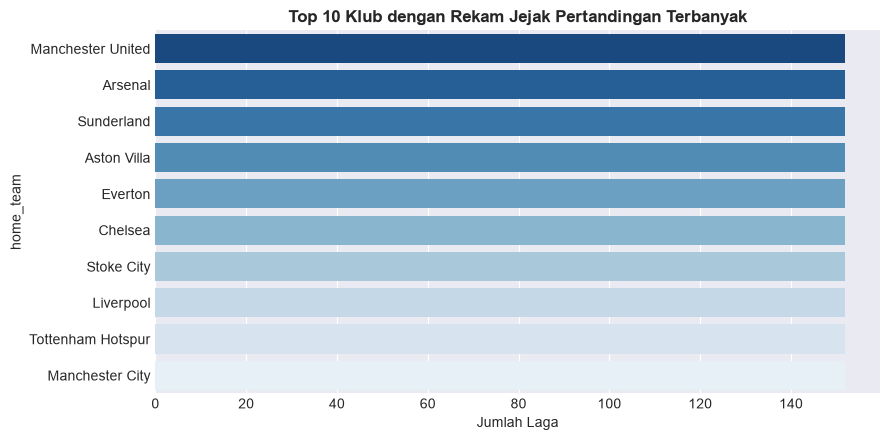

In [7]:
top_teams = df['home_team'].value_counts().head(10)

plt.figure(figsize=(9, 4.5))
sns.barplot(x=top_teams.values, y=top_teams.index, palette='Blues_r')
plt.title('Top 10 Klub dengan Rekam Jejak Pertandingan Terbanyak', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Laga', fontsize=10)
plt.tight_layout()
plt.show()